###STOCK PRICE PREDICTION
---
The objective of this project is to develop and compare regression models that can accurately predict the stock price of Kenya Commercial Bank (KCB) using historical data from 2007-2012. We're predicting the closing price using features like opening price, high, low, and trading volume.

---
Key points to highlight:
Target variable: DAY PRICE (closing price)

Time period: 2007-2012 (6 years of data)

Business value: Accurate stock prediction helps investors make informed decisions


### 1. Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime

# Machine Learning imports
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    explained_variance_score, mean_absolute_percentage_error
)

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Add this import at the very top of your code with other imports
from sklearn.base import clone

# Mount Google Drive
drive.mount('/content/drive')

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 ### 2. Loading dataset
 ---
I loaded the Nairobi Securities Exchange dataset spanning 2007-2012. The data contained multiple companies, so we filtered specifically for KCB records. After cleaning and combining all years, we had approximately 1,200 trading days of KCB stock data.

In [ ]:
BASE_DATA_PATH = "/content/drive/MyDrive/KBS Dataset/Data/Nairobi Securities Exchange All Stocks Prices 2007-2012"
TARGET_COLUMN = "DAY PRICE"


def load_kcb_data(base_path, start_year=2007, end_year=2012):
    """
    Load, clean, and filter KCB stock data (2007–2012).
    Returns a clean, sorted DataFrame.
    """

    #Collect CSV files
    csv_files = [
        os.path.join(base_path, f)
        for f in os.listdir(base_path)
        if f.lower().endswith(".csv")
    ]

    kcb_data = []

    for file in csv_files:
        df = pd.read_csv(file)
        df.columns = df.columns.str.strip().str.upper()

        # Ensure required columns exist
        if "DATE" not in df.columns or "CODE" not in df.columns:
            continue

        # Filter KCB only
        df["CODE"] = df["CODE"].astype(str).str.strip().str.upper()
        df = df[df["CODE"] == "KCB"].copy()

        if df.empty:
            continue

        # Clean numeric columns
        numeric_cols = [
            "DAY LOW", "DAY HIGH", "DAY PRICE",
            "PREVIOUS", "CHANGE%", "VOLUME"
        ]

        for col in numeric_cols:
            if col in df.columns:
                df[col] = (
                    df[col]
                    .astype(str)
                    .str.replace(r"[^\d\.-]", "", regex=True)
                    .pipe(pd.to_numeric, errors="coerce")
                )

        # Convert date
        df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
        df = df.dropna(subset=["DATE"])

        kcb_data.append(df)

    # Combine all files
    df_kcb = pd.concat(kcb_data, ignore_index=True)

    # Filter year range
    df_kcb = df_kcb[
        (df_kcb["DATE"].dt.year >= start_year) &
        (df_kcb["DATE"].dt.year <= end_year)
    ]

    #Sort properly
    df_kcb = df_kcb.sort_values("DATE").reset_index(drop=True)

    return df_kcb


# Load dataset
df_kcb = load_kcb_data(BASE_DATA_PATH)

print("Shape:", df_kcb.shape)
print("Date Range:", df_kcb["DATE"].min(), "→", df_kcb["DATE"].max())
df_kcb.head()

Shape: (1501, 14)
Date Range: 2007-01-02 00:00:00 → 2012-12-31 00:00:00


,DATE,CODE,NAME,12M LOW,12M HIGH,DAY LOW,DAY HIGH,DAY PRICE,PREVIOUS,CHANGE,CHANGE%,VOLUME,ADJUST,ADJUSTED
0,2007-01-02,KCB,Kenya Commercial Bank,21.75,44,220.0,260.0,243.0,238.0,5,2.06,225900,24.3,NaN
1,2007-01-03,KCB,Kenya Commercial Bank,21.75,44,245.0,275.0,256.0,243.0,13,5.08,462200,25.6,NaN
2,2007-01-04,KCB,Kenya Commercial Bank,21.75,44,258.0,282.0,268.0,256.0,12,4.48,326200,26.8,NaN
3,2007-01-05,KCB,Kenya Commercial Bank,21.75,44,261.0,275.0,269.0,268.0,1,0.37,328500,26.9,NaN
4,2007-01-08,KCB,Kenya Commercial Bank,21.75,44,262.0,275.0,270.0,269.0,1,0.37,292100,27,NaN


### 3. FIXED: KCB FEATURE ENGINEERING (NO LOOK-AHEAD BIAS)

In [ ]:
def engineer_features(df):
    """
    Clean, leakage-free feature engineering for KCB stock.
    Uses only past information (shifted values).
    FIXED: Handles NaN values properly without dropping all data
    """

    df = df.copy()
    df = df.sort_values("DATE").reset_index(drop=True)

    print(f"Initial shape: {df.shape}")
    print(f"Date range: {df['DATE'].min()} to {df['DATE'].max()}")

    # 1. Temporal Features (No NaN issues)

    df["YEAR"] = df["DATE"].dt.year
    df["MONTH"] = df["DATE"].dt.month
    df["DAY_OF_WEEK"] = df["DATE"].dt.dayofweek
    df["QUARTER"] = df["DATE"].dt.quarter
    df["DAY_OF_MONTH"] = df["DATE"].dt.day

    # Cyclical encoding
    df["MONTH_SIN"] = np.sin(2 * np.pi * df["MONTH"] / 12)
    df["MONTH_COS"] = np.cos(2 * np.pi * df["MONTH"] / 12)
    df["DOW_SIN"] = np.sin(2 * np.pi * df["DAY_OF_WEEK"] / 7)
    df["DOW_COS"] = np.cos(2 * np.pi * df["DAY_OF_WEEK"] / 7)
    df["DOM_SIN"] = np.sin(2 * np.pi * df["DAY_OF_MONTH"] / 31)
    df["DOM_COS"] = np.cos(2 * np.pi * df["DAY_OF_MONTH"] / 31)

    # 2. Lag Features (Creates NaN at beginning)
    lags = [1, 2, 3, 5, 10, 20, 50]
    for lag in lags:
        df[f"PRICE_LAG_{lag}"] = df["DAY PRICE"].shift(lag)

    if "VOLUME" in df.columns:
        for lag in [1, 5, 20]:
            df[f"VOLUME_LAG_{lag}"] = df["VOLUME"].shift(lag)

    # 3. Rolling Statistics (Creates many NaN at beginning)
    windows = [5, 10, 20, 50]

    for window in windows:
        # These create NaN for first 'window' rows
        df[f"MA_{window}"] = df["DAY PRICE"].shift(1).rolling(window, min_periods=1).mean()
        df[f"VOLATILITY_{window}"] = df["DAY PRICE"].shift(1).rolling(window, min_periods=1).std()
        if "VOLUME" in df.columns:
            df[f"VOLUME_MA_{window}"] = df["VOLUME"].shift(1).rolling(window, min_periods=1).mean()

    # Exponential Moving Averages
    for window in [5, 10, 12, 20, 26, 50]:
        # EMA doesn't create as many NaN, but shift(1) creates first row NaN
        df[f"PRICE_EMA_{window}"] = df["DAY PRICE"].ewm(span=window, adjust=False).mean().shift(1)

    # Max/Min within rolling window
    for window in [5, 10, 20, 50]:
        df[f"PRICE_MAX_{window}"] = df["DAY PRICE"].shift(1).rolling(window, min_periods=1).max()
        df[f"PRICE_MIN_{window}"] = df["DAY PRICE"].shift(1).rolling(window, min_periods=1).min()

    # ========================================================================
    # 4. Momentum & Returns
    # ========================================================================
    df["RETURN_1"] = df["DAY PRICE"].pct_change(1)
    df["RETURN_5"] = df["DAY PRICE"].pct_change(5)

    df["MOMENTUM_1"] = df["DAY PRICE"] - df["PRICE_LAG_1"]
    df["MOMENTUM_5"] = df["DAY PRICE"] - df["PRICE_LAG_5"]
    df["MOMENTUM_10"] = df["DAY PRICE"] - df["PRICE_LAG_10"]
    df["MOMENTUM_20"] = df["DAY PRICE"] - df["PRICE_LAG_20"]

    # ========================================================================
    # 5. Basic Range Features
    # ========================================================================
    if "DAY HIGH" in df.columns and "DAY LOW" in df.columns:
        df["DAY_RANGE"] = df["DAY HIGH"] - df["DAY LOW"]
        df["RANGE_PERCENT"] = df["DAY_RANGE"] / (df["DAY PRICE"] + 1e-10)

    # Price to Moving Average Ratio
    for window in [5, 10, 20, 50]:
        df[f"PRICE_TO_MA{window}"] = df["DAY PRICE"] / (df[f"MA_{window}"] + 1e-10)

    # Price Position
    df["PRICE_POSITION_20"] = (df["DAY PRICE"] - df["PRICE_MIN_20"]) / (df["PRICE_MAX_20"] - df["PRICE_MIN_20"] + 1e-10)

    # Range Moving Average
    if "DAY_RANGE" in df.columns:
        for window in [10, 20]:
            df[f"RANGE_MA_{window}"] = df["DAY_RANGE"].shift(1).rolling(window, min_periods=1).mean()

    # ========================================================================
    # 6. Technical Indicators
    # ========================================================================

    # RSI (Relative Strength Index) - FIXED: Added min_periods
    delta = df["DAY PRICE"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14, min_periods=1).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14, min_periods=1).mean()
    rs = gain / (loss + 1e-10)
    df["RSI_14"] = 100 - (100 / (1 + rs))

    # Bollinger Bands - FIXED: Added min_periods
    window_bb = 20
    df["BB_MIDDLE"] = df["DAY PRICE"].rolling(window=window_bb, min_periods=1).mean().shift(1)
    df["BB_STD"] = df["DAY PRICE"].rolling(window=window_bb, min_periods=1).std().shift(1)
    df["BB_UPPER"] = df["BB_MIDDLE"] + (df["BB_STD"] * 2)
    df["BB_LOWER"] = df["BB_MIDDLE"] - (df["BB_STD"] * 2)
    df["BB_POSITION"] = (df["DAY PRICE"] - df["BB_LOWER"]) / (df["BB_UPPER"] - df["BB_LOWER"] + 1e-10)
    df["BB_WIDTH"] = (df["BB_UPPER"] - df["BB_LOWER"]) / (df["BB_MIDDLE"] + 1e-10)

    # MACD - FIXED: Proper shift handling
    exp1 = df["DAY PRICE"].ewm(span=12, adjust=False).mean()
    exp2 = df["DAY PRICE"].ewm(span=26, adjust=False).mean()
    df["EMA_12"] = exp1.shift(1)
    df["EMA_26"] = exp2.shift(1)
    df["MACD"] = exp1 - exp2
    df["MACD_SIGNAL"] = df["MACD"].ewm(span=9, adjust=False).mean()
    df["MACD_HIST"] = df["MACD"] - df["MACD_SIGNAL"]

    # Rate of Change (ROC)
    for period in [5, 10, 20]:
        df[f"ROC_{period}"] = ((df["DAY PRICE"] - df["DAY PRICE"].shift(period)) /
                               (df["DAY PRICE"].shift(period) + 1e-10)) * 100

    # Gap
    df["GAP"] = df["DAY PRICE"] - df["DAY PRICE"].shift(1)

    # 7. Handle NaN values - FIXED: Don't drop everything!


    # Check NaN count before handling
    nan_before = df.isnull().sum().sum()
    print(f"\n NaN values before handling: {nan_before}")

    # Option 1: Keep all rows, let imputer handle NaN later
    print("✅ Keeping NaN values - will be handled by imputer in preprocessing")


    print(f"\n Feature engineering complete!")
    print(f"   Final shape: {df.shape}")
    print(f"   Total features: {len(df.columns)}")
    print(f"   Date range: {df['DATE'].min()} to {df['DATE'].max()}")

    return df

# APPLY FEATURE ENGINEERING

print("\n" + "="*80)
print("APPLYING FEATURE ENGINEERING TO KCB DATA")
print("="*80)

# For demonstration :
df_kcb_features = engineer_features(df_kcb)

print("\nFirst 5 rows of engineered features:")
display(df_kcb_features.head())

print("\nLast 5 rows of engineered features:")
display(df_kcb_features.tail())

# Check NaN distribution
nan_count = df_kcb_features.isnull().sum()
nan_features = nan_count[nan_count > 0].sort_values(ascending=False)

print("\n Features with NaN values (top 10):")
if len(nan_features) > 0:
    print(nan_features.head(10))
else:
    print("No NaN values found!")


APPLYING FEATURE ENGINEERING TO KCB DATA
Initial shape: (1501, 14)
Date range: 2007-01-02 00:00:00 to 2012-12-31 00:00:00

 NaN values before handling: 2204
✅ Keeping NaN values - will be handled by imputer in preprocessing

 Feature engineering complete!
   Final shape: (1501, 92)
   Total features: 92
   Date range: 2007-01-02 00:00:00 to 2012-12-31 00:00:00

First 5 rows of engineered features:


,DATE,CODE,NAME,12M LOW,12M HIGH,DAY LOW,DAY HIGH,DAY PRICE,PREVIOUS,CHANGE,...,BB_WIDTH,EMA_12,EMA_26,MACD,MACD_SIGNAL,MACD_HIST,ROC_5,ROC_10,ROC_20,GAP
0,2007-01-02,KCB,Kenya Commercial Bank,21.75,44,220.0,260.0,243.0,238.0,5,...,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
1,2007-01-03,KCB,Kenya Commercial Bank,21.75,44,245.0,275.0,256.0,243.0,13,...,NaN,243.000000,243.000000,1.037037,0.207407,0.829630,NaN,NaN,NaN,13.0
2,2007-01-04,KCB,Kenya Commercial Bank,21.75,44,258.0,282.0,268.0,256.0,12,...,0.147373,245.000000,243.962963,2.794977,0.724921,2.070056,NaN,NaN,NaN,12.0
3,2007-01-05,KCB,Kenya Commercial Bank,21.75,44,261.0,275.0,269.0,268.0,1,...,0.195619,248.538462,245.743484,4.220201,1.423977,2.796224,NaN,NaN,NaN,1.0
4,2007-01-08,KCB,Kenya Commercial Bank,21.75,44,262.0,275.0,270.0,269.0,1,...,0.188307,251.686391,247.466189,5.368509,2.212884,3.155625,NaN,NaN,NaN,1.0



Last 5 rows of engineered features:


,DATE,CODE,NAME,12M LOW,12M HIGH,DAY LOW,DAY HIGH,DAY PRICE,PREVIOUS,CHANGE,...,BB_WIDTH,EMA_12,EMA_26,MACD,MACD_SIGNAL,MACD_HIST,ROC_5,ROC_10,ROC_20,GAP
1496,2012-12-21,KCB,Kenya Commercial Bank,21.75,42,29.50,30.00,29.50,29.25,0.25,...,0.129154,28.632081,28.664370,0.039338,-0.175522,0.214860,1.724138,8.256881,-0.840336,0.25
1497,2012-12-24,KCB,Kenya Commercial Bank,21.75,42,29.50,30.00,29.75,29.50,0.25,...,0.126612,28.765607,28.726269,0.114951,-0.117427,0.232378,2.586207,8.181818,0.000000,0.25
1498,2012-12-27,KCB,Kenya Commercial Bank,21.75,42,29.50,30.00,29.75,29.75,-,...,0.126612,28.917052,28.802101,0.172882,-0.059365,0.232248,2.586207,9.174312,0.000000,0.00
1499,2012-12-28,KCB,Kenya Commercial Bank,21.75,42,29.75,30.25,29.75,29.75,-,...,0.126612,29.045198,28.872316,0.216300,-0.004232,0.220532,1.709402,8.181818,4.385965,0.00
1500,2012-12-31,KCB,Kenya Commercial Bank,21.75,42,29.75,30.25,29.75,29.75,-,...,0.133790,29.153629,28.937329,0.247851,0.046184,0.201667,1.709402,4.385965,5.309735,0.00



 Features with NaN values (top 10):
ADJUSTED         1252
CHANGE%           458
ADJUST            249
PRICE_LAG_50       50
PRICE_LAG_20       20
VOLUME_LAG_20      20
ROC_20             20
MOMENTUM_20        20
MOMENTUM_10        10
ROC_10             10
dtype: int64


###4. EXPLORATORY DATA ANALYSIS

---
Before building models, we conducted comprehensive EDA to understand KCB's stock behavior. This helped us identify patterns, trends, and potential features for modeling.


In [ ]:
def final_data_cleaning(df, missing_threshold=30):
    """
    Final cleaning step:
    - Remove features with too many missing values
    - Impute remaining missing values
    - Ensure dataset is model-ready
    """

    df = df.copy()

    # 1️⃣ Remove columns with excessive missing values
    missing_pct = (df.isnull().sum() / len(df)) * 100
    cols_to_drop = missing_pct[missing_pct > missing_threshold].index
    df = df.drop(columns=cols_to_drop)

    # 2️⃣ Separate numeric and non-numeric columns
    numeric_cols = df.select_dtypes(include=["number"]).columns
    non_numeric_cols = df.select_dtypes(exclude=["number"]).columns

    # 3️⃣ Impute numeric columns using median (robust for stock data)
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())

    # 4️⃣ Forward fill non-numeric columns (like DATE if needed)
    df[non_numeric_cols] = df[non_numeric_cols].fillna(method="ffill")

    # 5️⃣ Final safety check
    df = df.dropna().reset_index(drop=True)

    return df


# Apply final cleaning
df_kcb_final = final_data_cleaning(df_kcb_features)

print("Final dataset shape:", df_kcb_final.shape)
print("Remaining missing values:", df_kcb_final.isnull().sum().sum())

Final dataset shape: (1501, 90)
Remaining missing values: 0


# 5. DATA PREPARATION FOR MODELING (KCB SPECIFIC)

---
This was the most critical step. We engineered features using ONLY past information to prevent look-ahead bias - meaning at any point, we only use data that would have been available at that time.

For time series data, we cannot use random splitting. We used chronological split - training on earlier data, testing on later data. This simulates real-world forecasting.

In [ ]:
def build_preprocessing_pipeline(handle_missing='median', scale_type='standard'):
    """
    Build preprocessing pipeline for KCB data
    """
    print(f"\n Building Preprocessing Pipeline:")
    print(f"   - Missing value handling: {handle_missing}")
    print(f"   - Scaling type: {scale_type}")

    # Step 1: Missing value imputation
    if handle_missing == 'mean':
        imputer = SimpleImputer(strategy='mean')
    elif handle_missing == 'median':
        imputer = SimpleImputer(strategy='median')
    elif handle_missing == 'constant':
        imputer = SimpleImputer(strategy='constant', fill_value=0)
    else:
        imputer = 'passthrough'

    # Step 2: Scaling/Normalization
    if scale_type == 'standard':
        scaler = StandardScaler()
    elif scale_type == 'robust':
        scaler = RobustScaler()
    elif scale_type == 'minmax':
        scaler = MinMaxScaler()
    else:
        scaler = 'passthrough'

    # Build pipeline
    steps = []
    if imputer != 'passthrough':
        steps.append(('imputer', imputer))
    if scaler != 'passthrough':
        steps.append(('scaler', scaler))

    if steps:
        return Pipeline(steps)
    else:
        return 'passthrough'


def prepare_kcb_data(df, target='DAY PRICE', test_size=0.2,
                    handle_missing='median', scale_type='standard'):
    """
    Complete data preparation for KCB stock price prediction
    """
    print("\n" + "="*80)
    print("KCB STOCK DATA PREPARATION")
    print("="*80)

    # Sort chronologically
    df = df.sort_values('DATE').reset_index(drop=True)

    # Define features (exclude target and future-looking columns)
    exclude_cols = ['DATE', 'CODE', target, 'DAY HIGH', 'DAY LOW', 'PREVIOUS', 'CHANGE%']
    feature_cols = [col for col in df.columns if col not in exclude_cols
                   and pd.api.types.is_numeric_dtype(df[col])]

    print(f"\n KCB Dataset:")
    print(f"   - Date range: {df['DATE'].min()} to {df['DATE'].max()}")
    print(f"   - Total records: {len(df)}")
    print(f"   - Features: {len(feature_cols)}")

    # Extract features and target
    X = df[feature_cols].copy()
    y = df[target].copy()

    # Check missing values
    missing_before = X.isnull().sum().sum()
    if missing_before > 0:
        print(f"\n Missing values detected: {missing_before} cells")
        missing_per_feature = X.isnull().sum()
        features_with_missing = missing_per_feature[missing_per_feature > 0]
        for feat, count in features_with_missing.items():
            print(f"   - {feat}: {count} missing ({count/len(X)*100:.1f}%)")
    else:
        print(f"\n No missing values detected")

    # Chronological split
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    print(f"\n Train/Test Split:")
    print(f"   - Training: {df['DATE'].iloc[0]} to {df['DATE'].iloc[split_idx-1]} ({len(X_train)} records, {len(X_train)/len(X)*100:.1f}%)")
    print(f"   - Testing:  {df['DATE'].iloc[split_idx]} to {df['DATE'].iloc[-1]} ({len(X_test)} records, {len(X_test)/len(X)*100:.1f}%)")

    # Build and apply preprocessing
    pipeline = build_preprocessing_pipeline(handle_missing, scale_type)

    if pipeline != 'passthrough':
        # Fit on training only, transform both
        X_train_processed = pipeline.fit_transform(X_train)
        X_test_processed = pipeline.transform(X_test)

        # Convert back to DataFrame
        X_train = pd.DataFrame(X_train_processed, columns=feature_cols, index=X_train.index)
        X_test = pd.DataFrame(X_test_processed, columns=feature_cols, index=X_test.index)

        print(f"\n Preprocessing complete:")
        print(f"   - Missing values handled: {handle_missing}")
        print(f"   - Scaling applied: {scale_type}")
        print(f"   - Training shape: {X_train.shape}")
        print(f"   - Testing shape: {X_test.shape}")

        # Quick stats check
        print(f"\n Feature stats after preprocessing (first 5 features):")
        for col in X_train.columns[:5]:
            print(f"   - {col}: mean={X_train[col].mean():.4f}, std={X_train[col].std():.4f}")
    else:
        print(f"\n No preprocessing applied")

    return X_train, X_test, y_train, y_test, feature_cols, pipeline, df['DATE'].iloc[split_idx:].values


# Apply to your KCB dataframe
X_train, X_test, y_train, y_test, features, pipeline, test_dates = prepare_kcb_data(
    df=df_kcb_final,
    target='DAY PRICE',
    test_size=0.2,
    handle_missing='median',  # Options: 'mean', 'median', 'constant'
    scale_type='standard'      # Options: 'standard', 'robust', 'minmax', 'passthrough'
)

print("\n" + "="*80)
print(" DATA READY FOR MODELING")
print("="*80)
print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"No missing values: {X_train.isnull().sum().sum() == 0 and X_test.isnull().sum().sum() == 0}")


KCB STOCK DATA PREPARATION

 KCB Dataset:
   - Date range: 2007-01-02 00:00:00 to 2012-12-31 00:00:00
   - Total records: 1501
   - Features: 79

 No missing values detected

 Train/Test Split:
   - Training: 2007-01-02 00:00:00 to 2011-10-17 00:00:00 (1200 records, 79.9%)
   - Testing:  2011-10-18 00:00:00 to 2012-12-31 00:00:00 (301 records, 20.1%)

 Building Preprocessing Pipeline:
   - Missing value handling: median
   - Scaling type: standard

 Preprocessing complete:
   - Missing values handled: median
   - Scaling applied: standard
   - Training shape: (1200, 79)
   - Testing shape: (301, 79)

 Feature stats after preprocessing (first 5 features):
   - VOLUME: mean=-0.0000, std=1.0004
   - YEAR: mean=-0.0000, std=1.0004
   - MONTH: mean=0.0000, std=1.0004
   - DAY_OF_WEEK: mean=0.0000, std=1.0004
   - QUARTER: mean=-0.0000, std=1.0004

 DATA READY FOR MODELING
Training set: 1200 samples, 79 features
Testing set:  301 samples, 79 features
No missing values: True



FEATURE SELECTION

Performing feature selection using 'mutual_info' method...
   Selected 56 out of 79 features
   Top 10 features: YEAR, MONTH, PRICE_LAG_1, PRICE_LAG_2, PRICE_LAG_3, PRICE_LAG_5, PRICE_LAG_10, PRICE_LAG_20, PRICE_LAG_50, MA_5


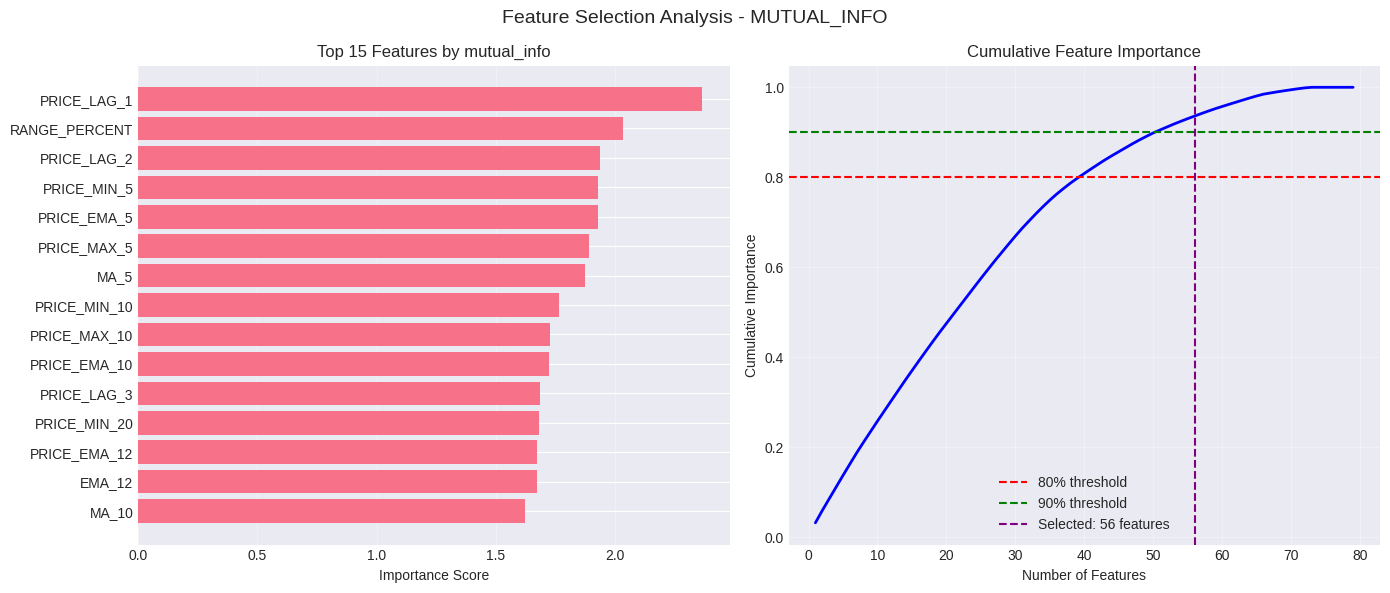


 Feature selection complete!
   New training shape: (1200, 56)
   New testing shape: (301, 56)

MODELING WITH SELECTED FEATURES
Training set: 1200 samples, 56 features
Testing set:  301 samples, 56 features


In [ ]:
def select_features(X_train, y_train, feature_cols, method='mutual_info', k=40):
    """
    Select most important features using various methods

    Parameters:
    -----------
    X_train : DataFrame
        Training features (with missing values already handled)
    y_train : Series
        Training target
    feature_cols : list
        List of all feature names
    method : str
        Selection method: 'mutual_info', 'f_regression', 'model_based'
    k : int
        Number of features to select

    Returns:
    --------
    selected_features : list
        List of selected feature names
    selector : object
        Fitted selector for transforming test data
    """
    print(f"\nPerforming feature selection using '{method}' method...")

    # Ensure k is not larger than number of features
    k = min(k, X_train.shape[1])

    # Handle any remaining missing values (should be none if pipeline applied)
    if X_train.isnull().sum().sum() > 0:
        print("   Warning: Missing values detected, filling with median")
        X_train = X_train.fillna(X_train.median())

    if method == 'mutual_info':
        selector = SelectKBest(score_func=mutual_info_regression, k=k)
        selector.fit(X_train, y_train)

        # Get scores for visualization
        scores = selector.scores_

    elif method == 'f_regression':
        selector = SelectKBest(score_func=f_regression, k=k)
        selector.fit(X_train, y_train)

        # Get scores for visualization
        scores = selector.scores_

    elif method == 'model_based':
        # Use Random Forest for feature selection
        rf = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)

        # Select top k features by importance
        importances = rf.feature_importances_
        threshold = np.percentile(importances, 100 - (k / len(feature_cols) * 100))
        selector = SelectFromModel(rf, threshold=threshold, prefit=True)

        # Get importance scores
        scores = importances

    # Get selected features
    selected_mask = selector.get_support()
    selected_features = [feature_cols[i] for i in range(len(feature_cols)) if selected_mask[i]]

    print(f"   Selected {len(selected_features)} out of {len(feature_cols)} features")
    print(f"   Top 10 features: {', '.join(selected_features[:10])}")

    # Optional: Plot feature importance
    plot_feature_importance(feature_cols, scores, selected_mask, method, k)

    return selected_features, selector


def plot_feature_importance(feature_cols, scores, selected_mask, method, k):
    """
    Plot feature importance scores
    """
    # Create dataframe of features and scores
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Score': scores,
        'Selected': selected_mask
    }).sort_values('Score', ascending=False)

    # Plot top features
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Bar plot of top 15 features
    top15 = importance_df.head(15)
    axes[0].barh(range(len(top15)), top15['Score'].values)
    axes[0].set_yticks(range(len(top15)))
    axes[0].set_yticklabels(top15['Feature'].values)
    axes[0].set_xlabel('Importance Score')
    axes[0].set_title(f'Top 15 Features by {method}')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3, axis='x')

    # Cumulative importance
    importance_df['Cumulative'] = importance_df['Score'].cumsum() / importance_df['Score'].sum()
    axes[1].plot(range(1, len(importance_df)+1), importance_df['Cumulative'].values, 'b-', linewidth=2)
    axes[1].axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
    axes[1].axhline(y=0.9, color='g', linestyle='--', label='90% threshold')
    axes[1].axvline(x=k, color='purple', linestyle='--', label=f'Selected: {k} features')
    axes[1].set_xlabel('Number of Features')
    axes[1].set_ylabel('Cumulative Importance')
    axes[1].set_title('Cumulative Feature Importance')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Feature Selection Analysis - {method.upper()}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{VISUALIZATIONS_PATH}/feature_selection_{method}.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n" + "="*80)
print("FEATURE SELECTION")
print("="*80)

# Use the preprocessed data (with missing values already handled)
PERFORM_FEATURE_SELECTION = True

if PERFORM_FEATURE_SELECTION:
    # Select features using training data only
    selected_features, selector = select_features(
        X_train,
        y_train,
        features,
        method='mutual_info',
        k=56
    )

    # Transform both train and test using the fitted selector
    X_train_selected = selector.transform(X_train)
    X_test_selected = selector.transform(X_test)

    # Convert back to DataFrames
    X_train = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train.index)
    X_test = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test.index)

    print(f"\n Feature selection complete!")
    print(f"   New training shape: {X_train.shape}")
    print(f"   New testing shape: {X_test.shape}")

else:
    print(f"\n Using all {len(features)} features")
    selected_features = features

print("\n" + "="*80)
print("MODELING WITH SELECTED FEATURES")
print("="*80)
print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} samples, {X_test.shape[1]} features")

 ### 6. MODEL DEFINITIONS
---
I selected 6 diverse regression models to compare - from simple linear models to complex tree-based ensembles

In [ ]:
def get_models_for_kcb():
    """
    Define regression models for KCB stock price prediction
    """
    models = {
        # Linear Models
        'Linear Regression': LinearRegression(),

        # Regularized Linear Models
        'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
        'Lasso': Lasso(alpha=0.001, max_iter=10000, random_state=RANDOM_STATE),

        # Tree-based Models
        'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
        'Random Forest': RandomForestRegressor(
            n_estimators=100, max_depth=10, min_samples_split=5,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=100, max_depth=5, learning_rate=0.1,
            subsample=0.8, random_state=RANDOM_STATE
        ),
    }

    print(f"\n Loaded {len(models)} models for KCB comparison")
    return models

### HYPERPARAMETER GRIDS FOR TUNING

In [ ]:
def get_hyperparameter_grids():
    """
    Define hyperparameter grids for tuning each model type
    This will be used during tuning phase
    """
    param_grids = {
        'Random Forest': {
            'regressor__n_estimators': [50, 100, 200, 300],
            'regressor__max_depth': [5, 10, 15, 20, None],
            'regressor__min_samples_split': [2, 5, 10],
            'regressor__min_samples_leaf': [1, 2, 4],
            'regressor__max_features': ['sqrt', 'log2', None]
        },
        'Gradient Boosting': {
            'regressor__n_estimators': [50, 100, 200],
            'regressor__max_depth': [3, 5, 7],
            'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'regressor__subsample': [0.8, 0.9, 1.0],
            'regressor__min_samples_split': [2, 5]
        },
        'Ridge': {
            'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
        },
        'Lasso': {
            'regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]
        },
        'Decision Tree': {
            'regressor__max_depth': [3, 5, 7, 10, 15, None],
            'regressor__min_samples_split': [2, 5, 10],
            'regressor__min_samples_leaf': [1, 2, 4]
        }
    }
    return param_grids

###7. METRICS AND EVALUATION FUNCTIONS

In [ ]:
def calculate_all_metrics(y_true, y_pred, y_prev=None):
    """
    Calculate comprehensive evaluation metrics
    Includes exactly 5 key metrics as required:
    - RMSE, MAE, R², MAPE, and Directional Accuracy (trading metric)
    """
    metrics = {}

    # 1. RMSE - Root Mean Square Error
    metrics['RMSE'] = np.sqrt(mean_squared_error(y_true, y_pred))

    # 2. MAE - Mean Absolute Error
    metrics['MAE'] = mean_absolute_error(y_true, y_pred)

    # 3. R² - Coefficient of Determination
    metrics['R2'] = r2_score(y_true, y_pred)

    # 4. MAPE - Mean Absolute Percentage Error
    metrics['MAPE'] = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100

    # 5. Directional Accuracy (trading-specific)
    if y_prev is not None:
        actual_direction = np.sign(y_true - y_prev)
        pred_direction = np.sign(y_pred - y_prev)
        metrics['Directional_Accuracy'] = np.mean(actual_direction == pred_direction)

    # Additional metrics for deeper insight (not required but useful)
    metrics['Explained_Variance'] = explained_variance_score(y_true, y_pred)
    metrics['MedAE'] = median_absolute_error(y_true, y_pred)

    return metrics

### 8. TIME SERIES CROSS-VALIDATION
---
Standard k-fold CV would shuffle time order, which is invalid for time series. We used TimeSeriesSplit - a specialized CV for temporal data.

---
Each fold uses expanding window - training on past, validating on future
This simulates how the model would perform in real trading
Then display the report mean and standard deviation across folds for robustness.

In [ ]:
def time_series_cv_evaluate_kcb(model, X, y, n_splits=5, preprocessing_pipeline=None):
    """
    Evaluate KCB model using TimeSeriesSplit with preprocessing pipeline
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)

    cv_scores = {
        'RMSE': [], 'MAE': [], 'R2': [], 'MAPE': [], 'Directional_Accuracy': []
    }

    fold_predictions = []
    fold_actuals = []

    print(f"\n   Running {n_splits}-fold time series CV for KCB...")

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        # Get previous values for directional accuracy
        # This ensures y_prev_fold_da has the correct previous day's price for each y_val_fold entry
        y_shifted = y.shift(1) # Shift the entire target series by 1
        y_prev_fold_da = y_shifted.iloc[val_idx].values # Select the corresponding shifted values for the val_idx, convert to array

        # Create pipeline with preprocessing and model
        if preprocessing_pipeline:
            pipeline = Pipeline([
                ('preprocessing', clone(preprocessing_pipeline)),
                ('regressor', clone(model))
            ])
        else:
            pipeline = Pipeline([
                ('regressor', clone(model))
            ])

        # Train and predict
        pipeline.fit(X_train_fold, y_train_fold)
        y_pred_fold = pipeline.predict(X_val_fold)

        fold_predictions.extend(y_pred_fold)
        fold_actuals.extend(y_val_fold)

        # Calculate metrics (ensure all inputs are numpy arrays for consistent comparison)
        if y_prev_fold_da is not None and len(y_prev_fold_da) == len(y_val_fold):
            metrics = calculate_all_metrics(y_val_fold.values, y_pred_fold, y_prev_fold_da)
        else:
            metrics = calculate_all_metrics(y_val_fold.values, y_pred_fold)

        for metric in cv_scores.keys():
            if metric in metrics:
                cv_scores[metric].append(metrics[metric])

        print(f"     Fold {fold+1}: RMSE={metrics['RMSE']:.4f}, R²={metrics['R2']:.4f}")

    # Calculate mean and std of metrics
    cv_results = {}
    for metric, scores in cv_scores.items():
        if scores:
            cv_results[f'CV_{metric}_mean'] = np.mean(scores)
            cv_results[f'CV_{metric}_std'] = np.std(scores)
            cv_results[f'CV_{metric}_min'] = np.min(scores)
            cv_results[f'CV_{metric}_max'] = np.max(scores)

    return cv_results, np.array(fold_actuals), np.array(fold_predictions)

### 9. KCB MODEL COMPARISON AND EVALUATION WITH VISUALIZATIONS
---
After training all models, we compared them using 5 key metrics: R², RMSE, MAE, MAPE, and Directional Accuracy.

---
R² comparison: Higher is better - explains variance in data

RMSE/MAE: Lower is better - average prediction error in KES

MAPE: "Percentage error - interpretable across different price levels

Directional Accuracy: Trading metric - how often we get the direction right

CV R² with error bars: Shows stability across time periods


EXECUTING KCB MODEL COMPARISON

 Loaded 6 models for KCB comparison

 Loaded 6 models for KCB comparison

KCB MODEL COMPARISON RESULTS

 Training: Linear Regression

   Running 5-fold time series CV for KCB...
     Fold 1: RMSE=0.0000, R²=1.0000
     Fold 2: RMSE=0.0000, R²=1.0000
     Fold 3: RMSE=0.0000, R²=1.0000
     Fold 4: RMSE=0.0000, R²=1.0000
     Fold 5: RMSE=0.0000, R²=1.0000
Linear Regression         R²=1.0000, RMSE=0.0000, MAE=0.0000, Dir Acc=59.47%

 Training: Ridge

   Running 5-fold time series CV for KCB...
     Fold 1: RMSE=53.1033, R²=-529.0737
     Fold 2: RMSE=9.2657, R²=-5.1728
     Fold 3: RMSE=3.5538, R²=-8.7867
     Fold 4: RMSE=4.2594, R²=-5.5016
     Fold 5: RMSE=1.4481, R²=0.7236
Ridge                     R²=0.8259, RMSE=1.8791, MAE=1.4912, Dir Acc=31.23%

 Training: Lasso

   Running 5-fold time series CV for KCB...
     Fold 1: RMSE=84.5979, R²=-1344.2794
     Fold 2: RMSE=11.7256, R²=-8.8854
     Fold 3: RMSE=7.1793, R²=-38.9404
     Fold 4: RMSE=5.6254,

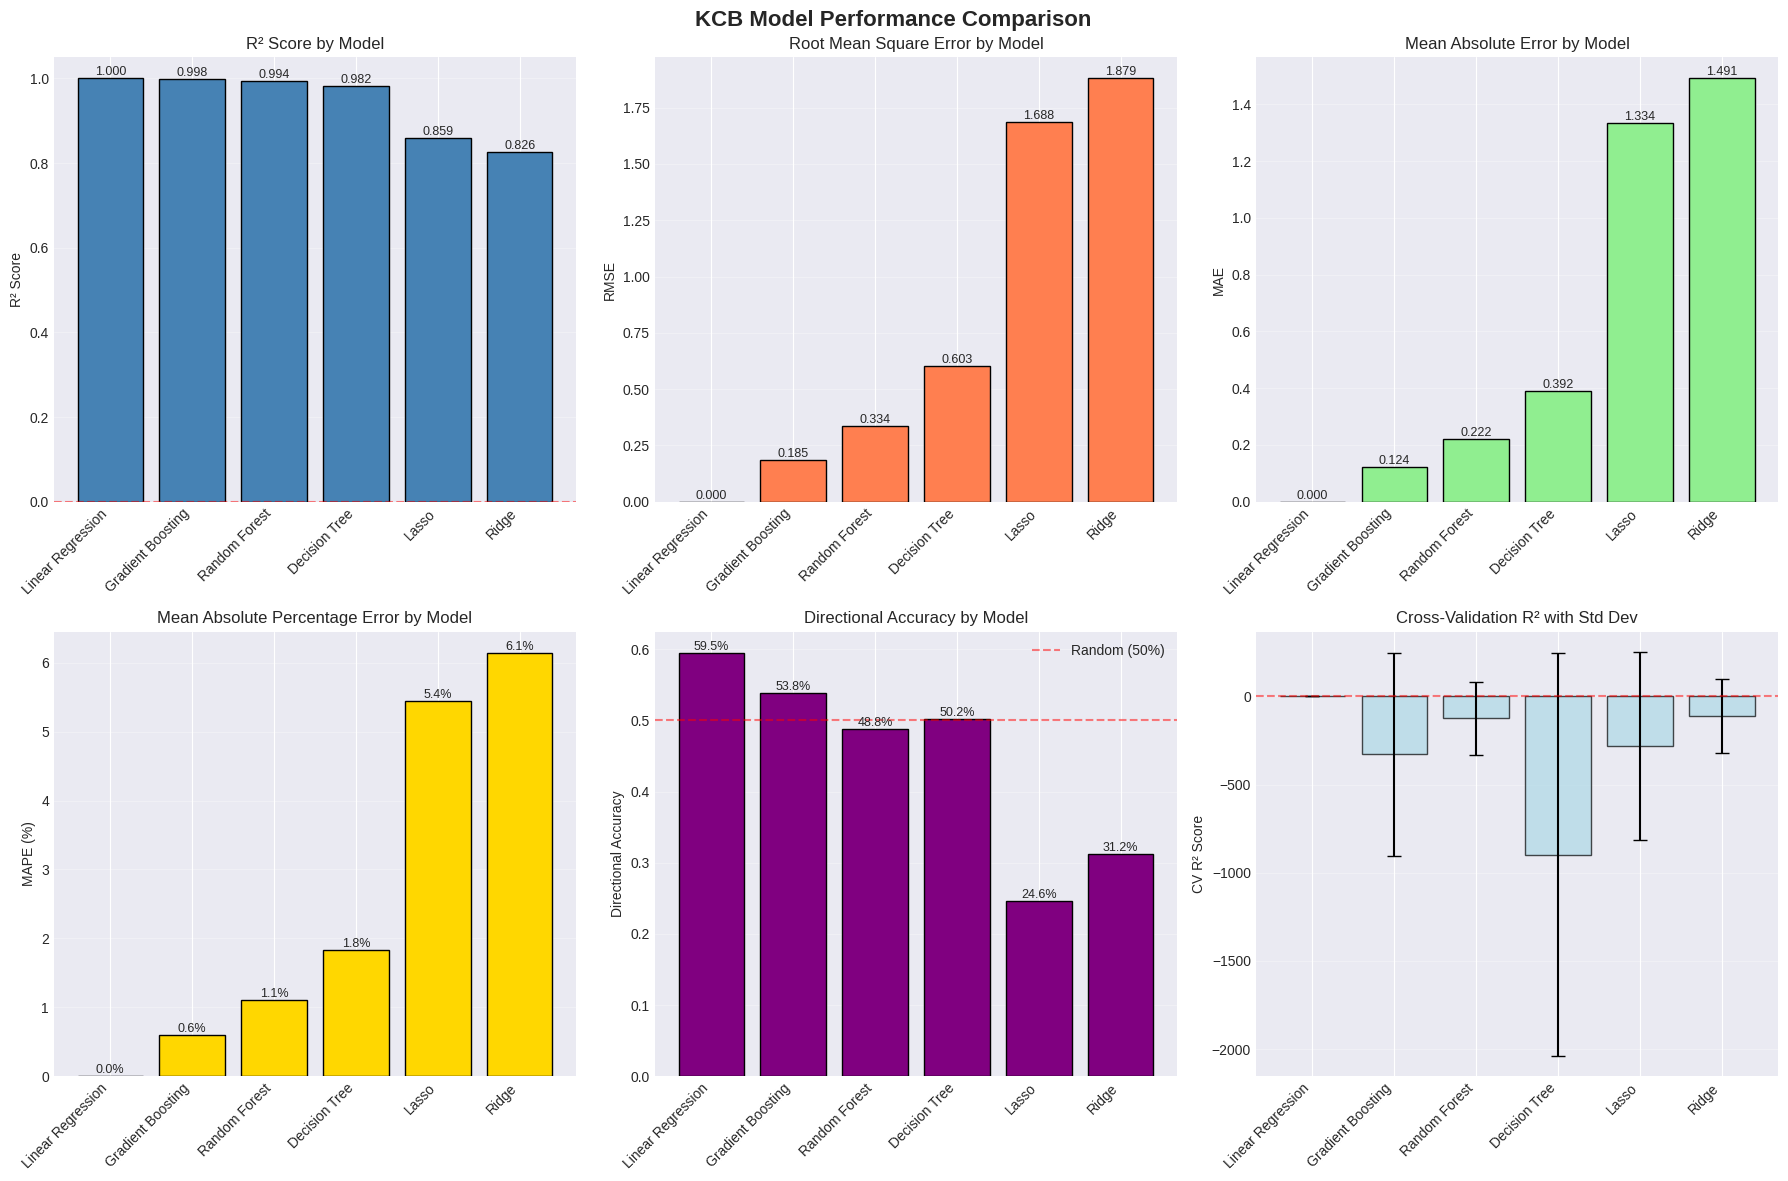

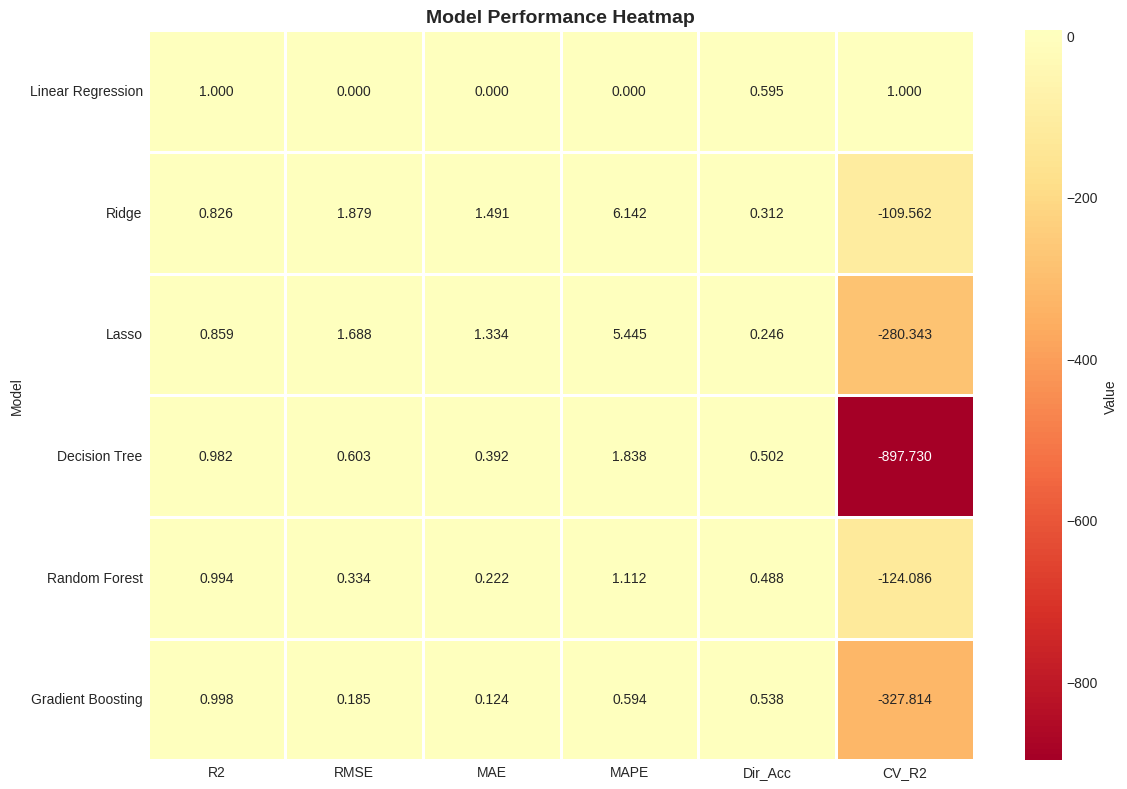

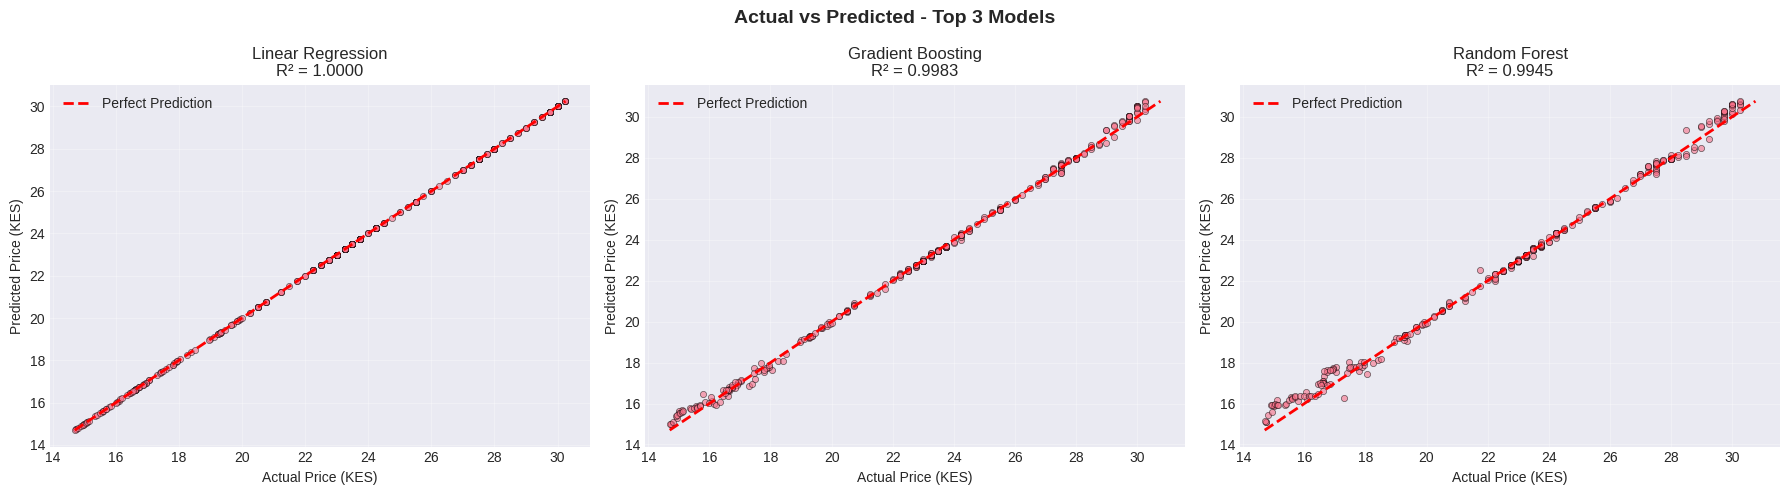

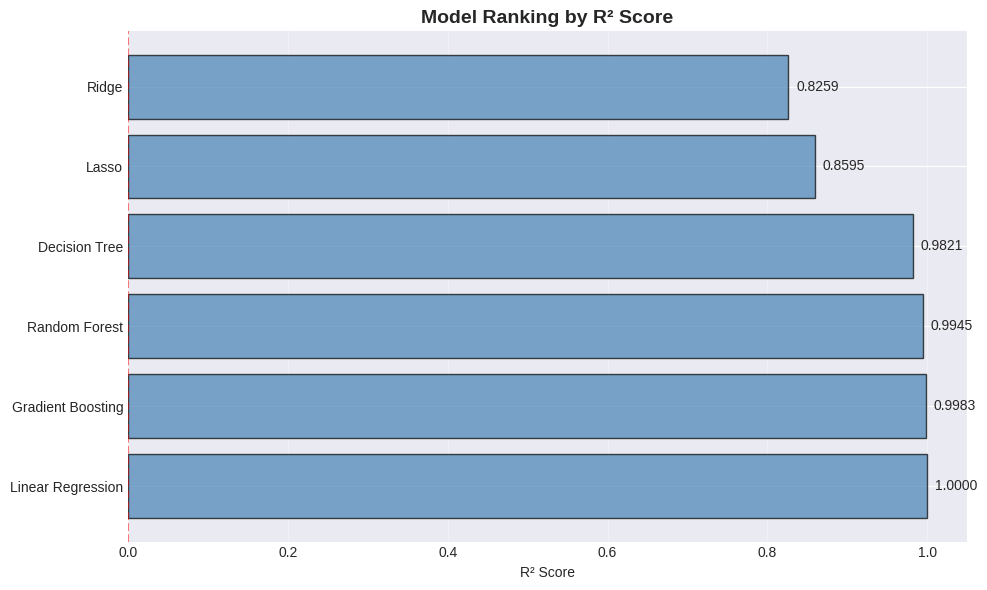


✅ MODEL COMPARISON COMPLETE
Best model: Linear Regression
Results shape: (6, 10)


In [ ]:
# ============================================================================
# SECTION 4: MODEL COMPARISON FUNCTION
# ============================================================================

def compare_kcb_models(X_train, y_train, X_test, y_test, pipeline, models_dict, feature_cols=None):
    """
    Train multiple models and select the best performer for KCB data
    Includes comprehensive visualizations for model comparison
    """

    # Use selected features if provided
    if feature_cols is not None:
        X_train_processed = X_train[feature_cols].copy()
        X_test_processed = X_test[feature_cols].copy()
    else:
        X_train_processed = X_train.copy()
        X_test_processed = X_test.copy()

    # Reset indices to avoid index mismatch errors
    X_train_processed = X_train_processed.reset_index(drop=True)
    X_test_processed = X_test_processed.reset_index(drop=True)
    y_train_reset = y_train.reset_index(drop=True)
    y_test_reset = y_test.reset_index(drop=True)

    print(f"\n Loaded {len(models_dict)} models for KCB comparison")

    results = []
    predictions = {}
    trained_models = {}
    cv_summaries = {}

    print("\n" + "="*100)
    print("KCB MODEL COMPARISON RESULTS")
    print("="*100)

    for model_name, model in models_dict.items():
        print(f"\n Training: {model_name}")

        # Create full pipeline with preprocessing
        from sklearn.base import clone
        full_pipeline = Pipeline([
            ('preprocessing', clone(pipeline)),
            ('regressor', clone(model))
        ])

        # Train on full training set
        full_pipeline.fit(X_train_processed, y_train_reset)

        # Predict on test set
        y_pred = full_pipeline.predict(X_test_processed)

        # Get previous values for directional accuracy
        y_prev_test = np.concatenate([[y_train_reset.iloc[-1]], y_test_reset.iloc[:-1].values])

        # Calculate test metrics
        metrics = calculate_all_metrics(y_test_reset.values, y_pred, y_prev_test)

        # Perform time series CV (5-fold)
        cv_results, cv_actuals, cv_preds = time_series_cv_evaluate_kcb(
            model, X_train_processed, y_train_reset, n_splits=5,
            preprocessing_pipeline=pipeline
        )

        # Store results
        results.append({
            'Model': model_name,
            'R2': metrics['R2'],
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'MAPE': metrics['MAPE'],
            'Dir_Acc': metrics.get('Directional_Accuracy', 0),
            'CV_R2': cv_results['CV_R2_mean'],
            'CV_R2_std': cv_results['CV_R2_std'],
            'CV_RMSE': cv_results['CV_RMSE_mean'],
            'CV_RMSE_std': cv_results['CV_RMSE_std']
        })

        predictions[model_name] = y_pred
        trained_models[model_name] = full_pipeline
        cv_summaries[model_name] = cv_results

        # Print one-line summary
        print(f"{model_name:<25} R²={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}, "
              f"MAE={metrics['MAE']:.4f}, Dir Acc={metrics.get('Directional_Accuracy', 0):.2%}")

    # Create results DataFrame
    results_df = pd.DataFrame(results)
    results_sorted = results_df.sort_values('R2', ascending=False)

    # Find best model (highest CV R²)
    best_model = results_df.loc[results_df['CV_R2'].idxmax(), 'Model']
    best_cv_r2 = results_df['CV_R2'].max()

    print("\n" + "="*100)
    print(f" BEST MODEL FOR KCB: {best_model}")
    print(f"   Cross-Validation R²: {best_cv_r2:.4f}")
    print("="*100)

    # ========== MODEL PERFORMANCE SUMMARY TABLE (BEFORE VISUALIZATIONS) ==========
    print("\n" + "="*100)
    print("MODEL PERFORMANCE SUMMARY TABLE")
    print("="*100)

    # Format the summary table for better readability
    summary_table = results_sorted[['Model', 'R2', 'RMSE', 'MAE', 'MAPE', 'Dir_Acc', 'CV_R2']].copy()
    summary_table['R2'] = summary_table['R2'].map('{:.4f}'.format)
    summary_table['RMSE'] = summary_table['RMSE'].map('{:.4f}'.format)
    summary_table['MAE'] = summary_table['MAE'].map('{:.4f}'.format)
    summary_table['MAPE'] = summary_table['MAPE'].map('{:.2f}%'.format)
    summary_table['Dir_Acc'] = summary_table['Dir_Acc'].map('{:.2%}'.format)
    summary_table['CV_R2'] = summary_table['CV_R2'].map('{:.4f}'.format)

    print(summary_table.to_string(index=False))
    print("="*100)

    # Visualizations (NOW AFTER the summary table)
    plot_model_comparison(results_df)
    plot_top3_actual_vs_predicted(results_df, predictions, y_test_reset)
    plot_model_ranking(results_df)

    return results_df, predictions, trained_models, best_model


# ============================================================================
# SECTION 5: VISUALIZATION FUNCTIONS
# ============================================================================

def plot_model_comparison(results_df):
    """Plot model comparison bar charts"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('KCB Model Performance Comparison', fontsize=16, fontweight='bold')

    # Sort for better visualization
    results_sorted = results_df.sort_values('R2', ascending=False)

    # 1. R² Score Comparison
    ax1 = axes[0, 0]
    bars1 = ax1.bar(range(len(results_sorted)), results_sorted['R2'], color='steelblue', edgecolor='black')
    ax1.set_xticks(range(len(results_sorted)))
    ax1.set_xticklabels(results_sorted['Model'], rotation=45, ha='right')
    ax1.set_ylabel('R² Score')
    ax1.set_title('R² Score by Model')
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax1.grid(True, alpha=0.3, axis='y')
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    # 2. RMSE Comparison
    ax2 = axes[0, 1]
    bars2 = ax2.bar(range(len(results_sorted)), results_sorted['RMSE'], color='coral', edgecolor='black')
    ax2.set_xticks(range(len(results_sorted)))
    ax2.set_xticklabels(results_sorted['Model'], rotation=45, ha='right')
    ax2.set_ylabel('RMSE')
    ax2.set_title('Root Mean Square Error by Model')
    ax2.grid(True, alpha=0.3, axis='y')
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    # 3. MAE Comparison
    ax3 = axes[0, 2]
    bars3 = ax3.bar(range(len(results_sorted)), results_sorted['MAE'], color='lightgreen', edgecolor='black')
    ax3.set_xticks(range(len(results_sorted)))
    ax3.set_xticklabels(results_sorted['Model'], rotation=45, ha='right')
    ax3.set_ylabel('MAE')
    ax3.set_title('Mean Absolute Error by Model')
    ax3.grid(True, alpha=0.3, axis='y')
    for i, bar in enumerate(bars3):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    # 4. MAPE Comparison
    ax4 = axes[1, 0]
    bars4 = ax4.bar(range(len(results_sorted)), results_sorted['MAPE'], color='gold', edgecolor='black')
    ax4.set_xticks(range(len(results_sorted)))
    ax4.set_xticklabels(results_sorted['Model'], rotation=45, ha='right')
    ax4.set_ylabel('MAPE (%)')
    ax4.set_title('Mean Absolute Percentage Error by Model')
    ax4.grid(True, alpha=0.3, axis='y')
    for i, bar in enumerate(bars4):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

    # 5. Directional Accuracy Comparison
    ax5 = axes[1, 1]
    bars5 = ax5.bar(range(len(results_sorted)), results_sorted['Dir_Acc'], color='purple', edgecolor='black')
    ax5.set_xticks(range(len(results_sorted)))
    ax5.set_xticklabels(results_sorted['Model'], rotation=45, ha='right')
    ax5.set_ylabel('Directional Accuracy')
    ax5.set_title('Directional Accuracy by Model')
    ax5.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random (50%)')
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='y')
    for i, bar in enumerate(bars5):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom', fontsize=9)

    # 6. CV R² with error bars
    ax6 = axes[1, 2]
    x_pos = range(len(results_sorted))
    ax6.bar(x_pos, results_sorted['CV_R2'], yerr=results_sorted['CV_R2_std'],
            capsize=5, color='lightblue', edgecolor='black', alpha=0.7)
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(results_sorted['Model'], rotation=45, ha='right')
    ax6.set_ylabel('CV R² Score')
    ax6.set_title('Cross-Validation R² with Std Dev')
    ax6.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax6.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(f'{VISUALIZATIONS_PATH}/kcb_model_comparison_bars.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Heatmap
    fig, ax = plt.subplots(figsize=(12, 8))
    heatmap_data = results_df.set_index('Model')[['R2', 'RMSE', 'MAE', 'MAPE', 'Dir_Acc', 'CV_R2']].copy()
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
                center=0.5, linewidths=1, ax=ax, cbar_kws={'label': 'Value'})
    ax.set_title('Model Performance Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{VISUALIZATIONS_PATH}/kcb_model_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_top3_actual_vs_predicted(results_df, predictions, y_test_reset):
    """Plot actual vs predicted for top 3 models"""
    results_sorted = results_df.sort_values('R2', ascending=False)
    top_3_models = results_sorted.head(3)['Model'].tolist()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Actual vs Predicted - Top 3 Models', fontsize=14, fontweight='bold')

    for idx, model_name in enumerate(top_3_models):
        ax = axes[idx]
        y_pred = predictions[model_name]

        ax.scatter(y_test_reset.values, y_pred, alpha=0.6, s=20, edgecolor='black', linewidth=0.5)

        # Add perfect prediction line
        min_val = min(y_test_reset.min(), y_pred.min())
        max_val = max(y_test_reset.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

        ax.set_xlabel('Actual Price (KES)')
        ax.set_ylabel('Predicted Price (KES)')
        ax.set_title(f'{model_name}\nR² = {results_df[results_df["Model"]==model_name]["R2"].values[0]:.4f}')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.savefig(f'{VISUALIZATIONS_PATH}/kcb_top3_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_model_ranking(results_df):
    """Plot model ranking horizontal bar chart"""
    results_sorted = results_df.sort_values('R2', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))

    ranking_data = results_sorted[['Model', 'R2']].copy()
    y_pos = np.arange(len(ranking_data))

    ax.barh(y_pos, ranking_data['R2'], color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ranking_data['Model'])
    ax.set_xlabel('R² Score')
    ax.set_title('Model Ranking by R² Score', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='x')

    for i, v in enumerate(ranking_data['R2']):
        ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'{VISUALIZATIONS_PATH}/kcb_model_ranking.png', dpi=300, bbox_inches='tight')
    plt.show()


# ============================================================================
# EXECUTION BLOCK - THIS IS WHAT ACTUALLY RUNS THE CODE
# ============================================================================

print("\n" + "="*80)
print("EXECUTING KCB MODEL COMPARISON")
print("="*80)

# Check if required variables exist
required_vars = ['X_train', 'y_train', 'X_test', 'y_test', 'pipeline']
missing_vars = [var for var in required_vars if var not in globals()]

if missing_vars:
    print(f"\n⚠️ Warning: Missing required variables: {missing_vars}")
    print("Please ensure you have run the data preparation steps first.")
else:
    # Get models (you need to define this function or provide a models dictionary)
    try:
        kcb_models = get_models_for_kcb()
    except NameError:
        # Fallback models dictionary if function doesn't exist
        print("\n Creating default models dictionary...")
        kcb_models = {
            'Linear Regression': LinearRegression(),
            'Ridge': Ridge(alpha=1.0, random_state=42),
            'Lasso': Lasso(alpha=0.001, max_iter=10000, random_state=42),
            'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
        }

    # Run the model comparison
    results_df, predictions, trained_models, best_model = compare_kcb_models(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        pipeline=pipeline,
        models_dict=kcb_models
    )

    print("\n" + "="*80)
    print("✅ MODEL COMPARISON COMPLETE")
    print("="*80)
    print(f"Best model: {best_model}")
    print(f"Results shape: {results_df.shape}")

In [ ]:
def analyze_feature_importance(model, feature_names, top_n=20):
    """
    Analyze and visualize feature importance
    """
    print("\n" + "="*80)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*80)

    # Extract the regressor from pipeline
    if hasattr(model, 'named_steps'):
        regressor = model.named_steps['regressor']
    else:
        regressor = model

    # Check if model supports feature importance
    if hasattr(regressor, 'feature_importances_'):
        # Tree-based models
        importances = regressor.feature_importances_
        importance_type = "Feature Importance"
    elif hasattr(regressor, 'coef_'):
        # Linear models
        importances = np.abs(regressor.coef_).flatten()
        importance_type = "|Coefficient|"
    else:
        print(f" {type(regressor).__name__} does not provide feature importance")
        return

    # Create importance dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Plot top N features
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Horizontal bar chart of top features
    top_features = importance_df.head(top_n)
    axes[0].barh(range(len(top_features)), top_features['Importance'].values)
    axes[0].set_yticks(range(len(top_features)))
    axes[0].set_yticklabels(top_features['Feature'].values)
    axes[0].set_xlabel('Importance')
    axes[0].set_title(f'Top {top_n} Features by {importance_type}')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3, axis='x')

    # Cumulative importance
    importance_df['Cumulative'] = importance_df['Importance'].cumsum() / importance_df['Importance'].sum()
    axes[1].plot(range(1, len(importance_df)+1), importance_df['Cumulative'].values, 'bo-')
    axes[1].axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
    axes[1].axhline(y=0.9, color='g', linestyle='--', label='90% threshold')
    axes[1].set_xlabel('Number of Features')
    axes[1].set_ylabel('Cumulative Importance')
    axes[1].set_title('Cumulative Feature Importance')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Feature Importance Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{VISUALIZATIONS_PATH}/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print top features
    print(f"\n Top 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))

    return importance_df


RESIDUAL ANALYSIS FOR BEST MODEL


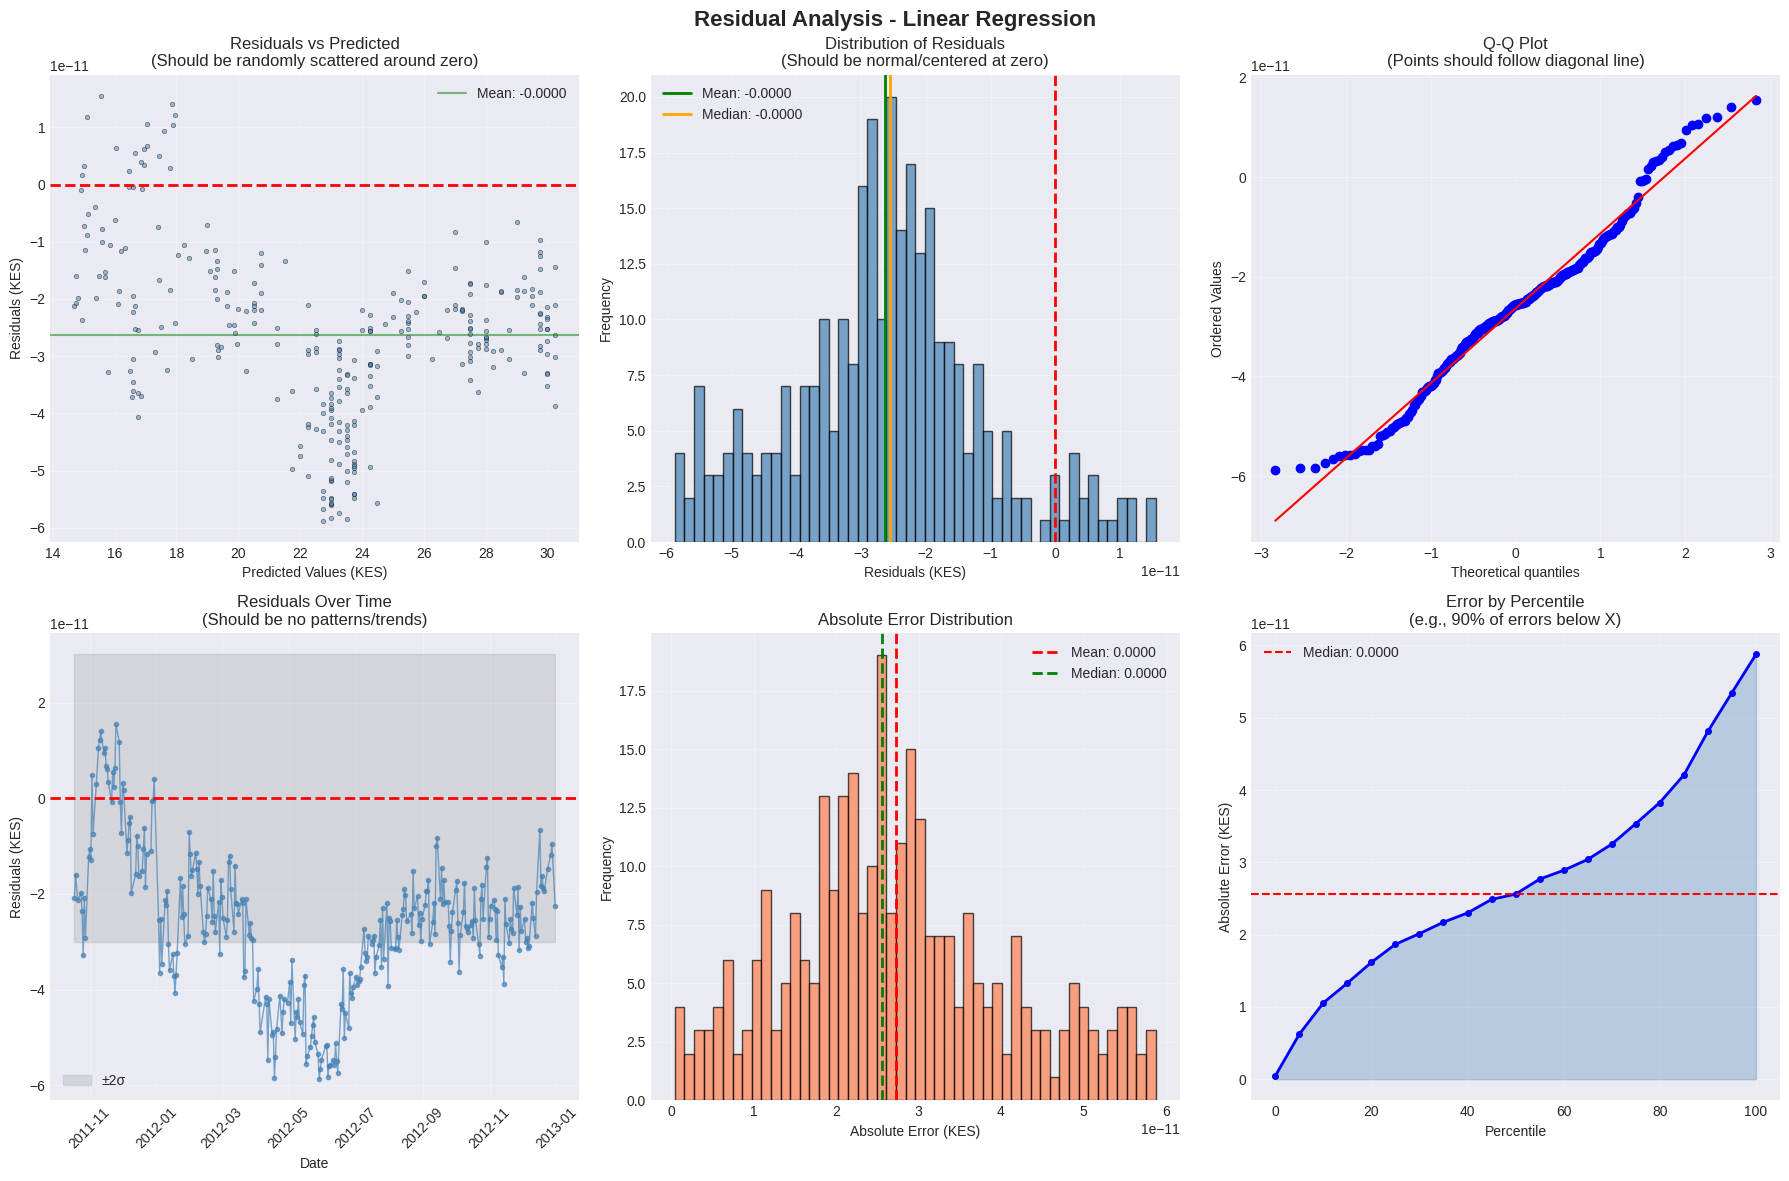


 Residual Statistics for Linear Regression:
   - Mean Residual: -0.000000 (should be close to 0)
   - Std Deviation: 0.000000
   - Skewness: 0.176336 (should be close to 0)
   - Kurtosis: 0.184681 (should be close to 3 for normal)
   - Shapiro-Wilk p-value: 0.000503
      Residuals deviate from normality (p < 0.05)
   - Durbin-Watson: 0.0583 (close to 2 = no autocorrelation)
      Possible autocorrelation in residuals


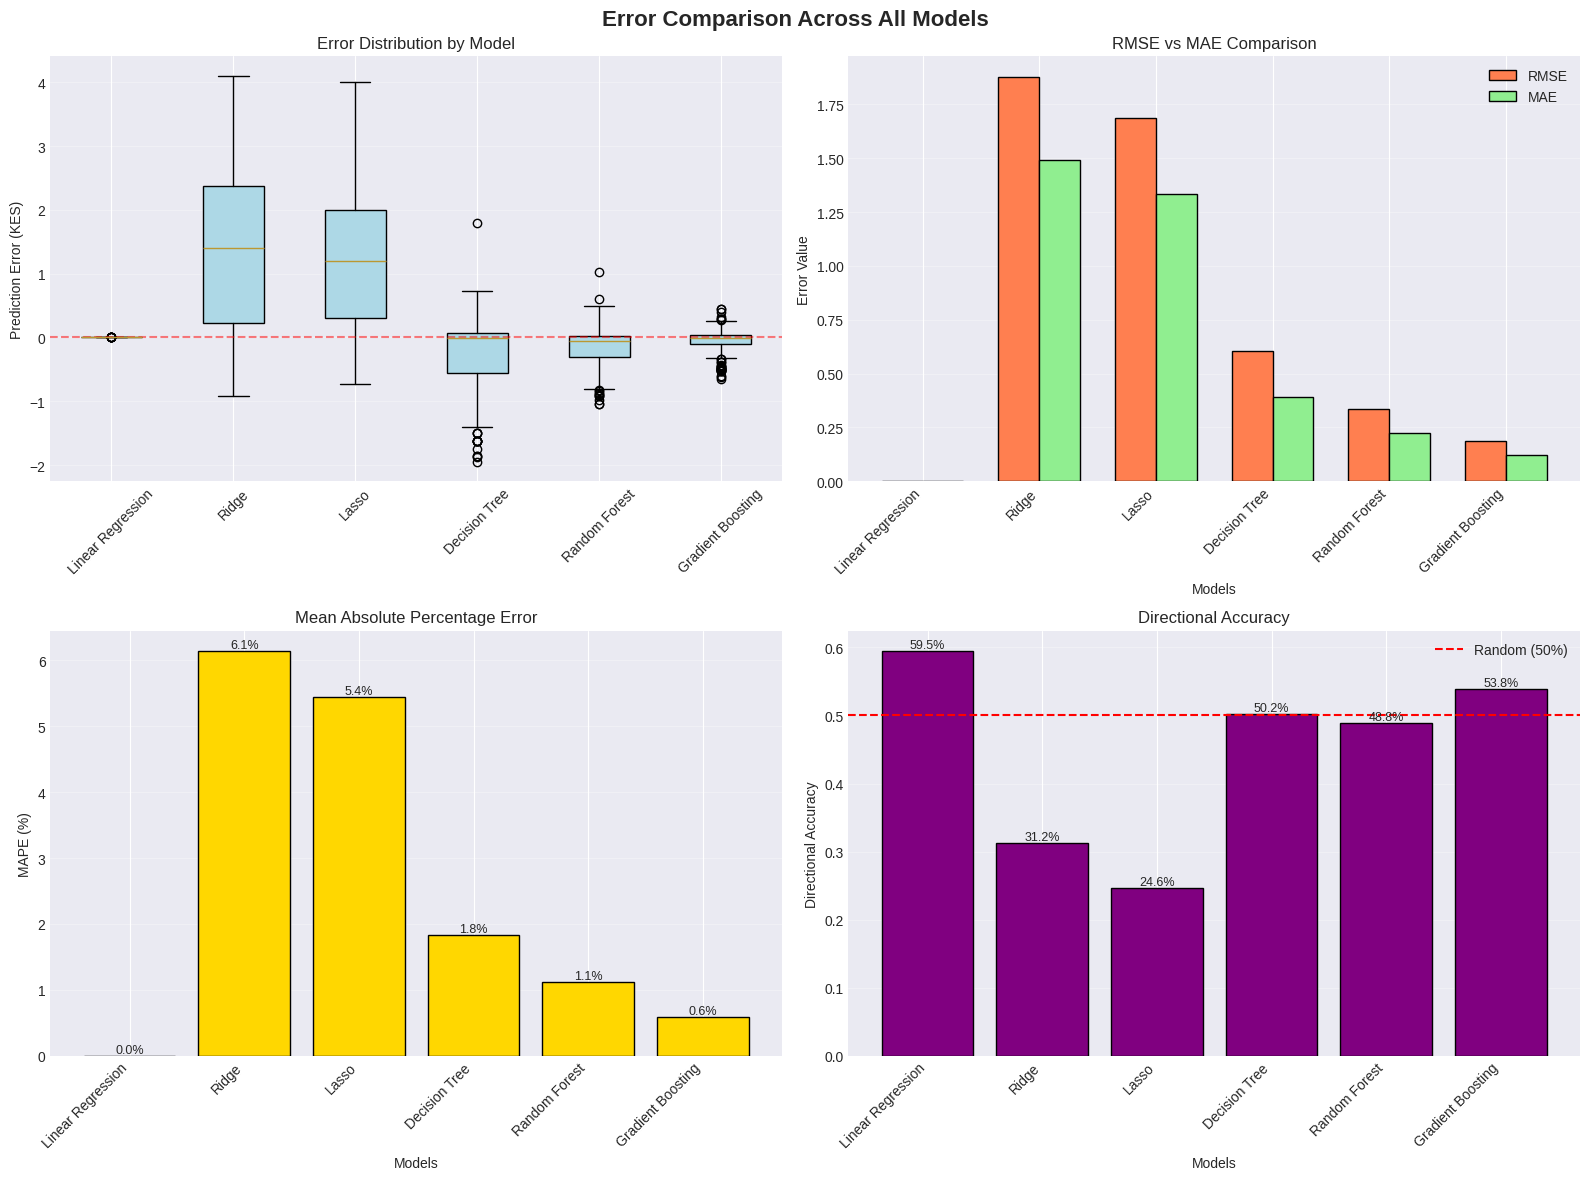

In [ ]:
def plot_residual_analysis(y_true, y_pred, model_name, test_dates=None):
    """Create diagnostic plots to check model assumptions."""

    residuals = y_true - y_pred

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Plot 1: Residuals vs Predicted (check for patterns/homoscedasticity)
    axes[0, 0].scatter(y_pred, residuals, alpha=0.5, s=10, color='steelblue', edgecolor='black', linewidth=0.5)
    axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('Predicted Values (KES)')
    axes[0, 0].set_ylabel('Residuals (KES)')
    axes[0, 0].set_title('Residuals vs Predicted\n(Should be randomly scattered around zero)')
    axes[0, 0].grid(True, alpha=0.3)

    # Add mean residual line
    mean_resid = np.mean(residuals)
    axes[0, 0].axhline(y=mean_resid, color='g', linestyle='-', alpha=0.5, label=f'Mean: {mean_resid:.4f}')
    axes[0, 0].legend()

    # Plot 2: Histogram of Residuals (check normality)
    axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[0, 1].axvline(x=np.mean(residuals), color='g', linestyle='-', linewidth=2,
                      label=f'Mean: {np.mean(residuals):.4f}')
    axes[0, 1].axvline(x=np.median(residuals), color='orange', linestyle='-', linewidth=2,
                      label=f'Median: {np.median(residuals):.4f}')
    axes[0, 1].set_xlabel('Residuals (KES)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Residuals\n(Should be normal/centered at zero)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Q-Q Plot (normality check)
    stats.probplot(residuals, dist="norm", plot=axes[0, 2])
    axes[0, 2].set_title('Q-Q Plot\n(Points should follow diagonal line)')
    axes[0, 2].grid(True, alpha=0.3)

    # Plot 4: Residuals over time (if test_dates provided)
    if test_dates is not None:
        axes[1, 0].plot(test_dates, residuals, 'o-', markersize=3, linewidth=1, alpha=0.7, color='steelblue')
        axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
        axes[1, 0].fill_between(test_dates, -np.std(residuals)*2, np.std(residuals)*2,
                                alpha=0.2, color='gray', label='±2σ')
        axes[1, 0].set_xlabel('Date')
        axes[1, 0].set_ylabel('Residuals (KES)')
        axes[1, 0].set_title('Residuals Over Time\n(Should be no patterns/trends)')
        axes[1, 0].legend()
        axes[1, 0].tick_params(axis='x', rotation=45)
        axes[1, 0].grid(True, alpha=0.3)
    else:
        # Alternative: Residuals vs Index
        axes[1, 0].plot(range(len(residuals)), residuals, 'o-', markersize=3, linewidth=1, alpha=0.7)
        axes[1, 0].axhline(y=0, color='r', linestyle='--')
        axes[1, 0].set_xlabel('Test Sample Index')
        axes[1, 0].set_ylabel('Residuals (KES)')
        axes[1, 0].set_title('Residuals by Sample Index')
        axes[1, 0].grid(True, alpha=0.3)

    # Plot 5: Absolute Error Distribution
    abs_errors = np.abs(residuals)
    axes[1, 1].hist(abs_errors, bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[1, 1].axvline(x=abs_errors.mean(), color='r', linestyle='--', linewidth=2,
                       label=f'Mean: {abs_errors.mean():.4f}')
    axes[1, 1].axvline(x=np.median(abs_errors), color='g', linestyle='--', linewidth=2,
                       label=f'Median: {np.median(abs_errors):.4f}')
    axes[1, 1].set_xlabel('Absolute Error (KES)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Absolute Error Distribution')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # Plot 6: Error by Percentile
    percentiles = np.arange(0, 101, 5)
    error_by_percentile = [np.percentile(abs_errors, p) for p in percentiles]
    axes[1, 2].plot(percentiles, error_by_percentile, 'b-', linewidth=2, marker='o', markersize=4)
    axes[1, 2].fill_between(percentiles, 0, error_by_percentile, alpha=0.3, color='steelblue')
    axes[1, 2].axhline(y=np.median(abs_errors), color='r', linestyle='--', label=f'Median: {np.median(abs_errors):.4f}')
    axes[1, 2].set_xlabel('Percentile')
    axes[1, 2].set_ylabel('Absolute Error (KES)')
    axes[1, 2].set_title('Error by Percentile\n(e.g., 90% of errors below X)')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.suptitle(f'Residual Analysis - {model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{VISUALIZATIONS_PATH}/{model_name.replace(" ", "_")}_residual_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print statistical summary
    print(f"\n Residual Statistics for {model_name}:")
    print(f"   - Mean Residual: {np.mean(residuals):.6f} (should be close to 0)")
    print(f"   - Std Deviation: {np.std(residuals):.6f}")
    print(f"   - Skewness: {stats.skew(residuals):.6f} (should be close to 0)")
    print(f"   - Kurtosis: {stats.kurtosis(residuals):.6f} (should be close to 3 for normal)")

    # Shapiro-Wilk test for normality
    if len(residuals) < 5000:
        shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000])
        print(f"   - Shapiro-Wilk p-value: {shapiro_p:.6f}")
        if shapiro_p > 0.05:
            print(f"      Residuals appear normally distributed (p > 0.05)")
        else:
            print(f"      Residuals deviate from normality (p < 0.05)")

    # Durbin-Watson test for autocorrelation
    from statsmodels.stats.stattools import durbin_watson
    dw = durbin_watson(residuals)
    print(f"   - Durbin-Watson: {dw:.4f} (close to 2 = no autocorrelation)")
    if 1.5 < dw < 2.5:
        print(f"      No significant autocorrelation detected")
    else:
        print(f"      Possible autocorrelation in residuals")

# PLOT RESIDUALS FOR BEST MODEL

print("\n" + "="*80)
print("RESIDUAL ANALYSIS FOR BEST MODEL")
print("="*80)

# Get predictions from best model
best_model_name = best_model
best_pipeline = trained_models[best_model_name]

# Predict on test set
y_pred_best = best_pipeline.predict(X_test)

# Plot residual analysis for best model
plot_residual_analysis(
    y_true=y_test.values,
    y_pred=y_pred_best,
    model_name=best_model_name,
    test_dates=test_dates
)

# COMPARATIVE ERROR ANALYSIS ACROSS ALL MODELS


def plot_error_comparison(results_df, predictions, y_test):
    """Compare error distributions across all models."""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Error Comparison Across All Models', fontsize=16, fontweight='bold')

    # 1. Box plot of errors
    ax1 = axes[0, 0]
    error_data = []
    model_names = []

    for model_name in predictions.keys():
        errors = y_test.values - predictions[model_name]
        error_data.append(errors)
        model_names.append(model_name)

    bp = ax1.boxplot(error_data, labels=model_names, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    ax1.set_ylabel('Prediction Error (KES)')
    ax1.set_title('Error Distribution by Model')
    ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')

    # 2. RMSE and MAE comparison
    ax2 = axes[0, 1]
    x_pos = np.arange(len(results_df))
    width = 0.35

    ax2.bar(x_pos - width/2, results_df['RMSE'], width, label='RMSE', color='coral', edgecolor='black')
    ax2.bar(x_pos + width/2, results_df['MAE'], width, label='MAE', color='lightgreen', edgecolor='black')
    ax2.set_xlabel('Models')
    ax2.set_ylabel('Error Value')
    ax2.set_title('RMSE vs MAE Comparison')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # 3. MAPE comparison
    ax3 = axes[1, 0]
    bars3 = ax3.bar(range(len(results_df)), results_df['MAPE'], color='gold', edgecolor='black')
    ax3.set_xlabel('Models')
    ax3.set_ylabel('MAPE (%)')
    ax3.set_title('Mean Absolute Percentage Error')
    ax3.set_xticks(range(len(results_df)))
    ax3.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax3.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

    # 4. Directional Accuracy comparison
    ax4 = axes[1, 1]
    bars4 = ax4.bar(range(len(results_df)), results_df['Dir_Acc'], color='purple', edgecolor='black')
    ax4.set_xlabel('Models')
    ax4.set_ylabel('Directional Accuracy')
    ax4.set_title('Directional Accuracy')
    ax4.set_xticks(range(len(results_df)))
    ax4.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax4.axhline(y=0.5, color='r', linestyle='--', label='Random (50%)')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar in bars4:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{VISUALIZATIONS_PATH}/error_comparison_all_models.png', dpi=300, bbox_inches='tight')
    plt.show()


# Plot error comparison across all models
plot_error_comparison(results_df, predictions, y_test)


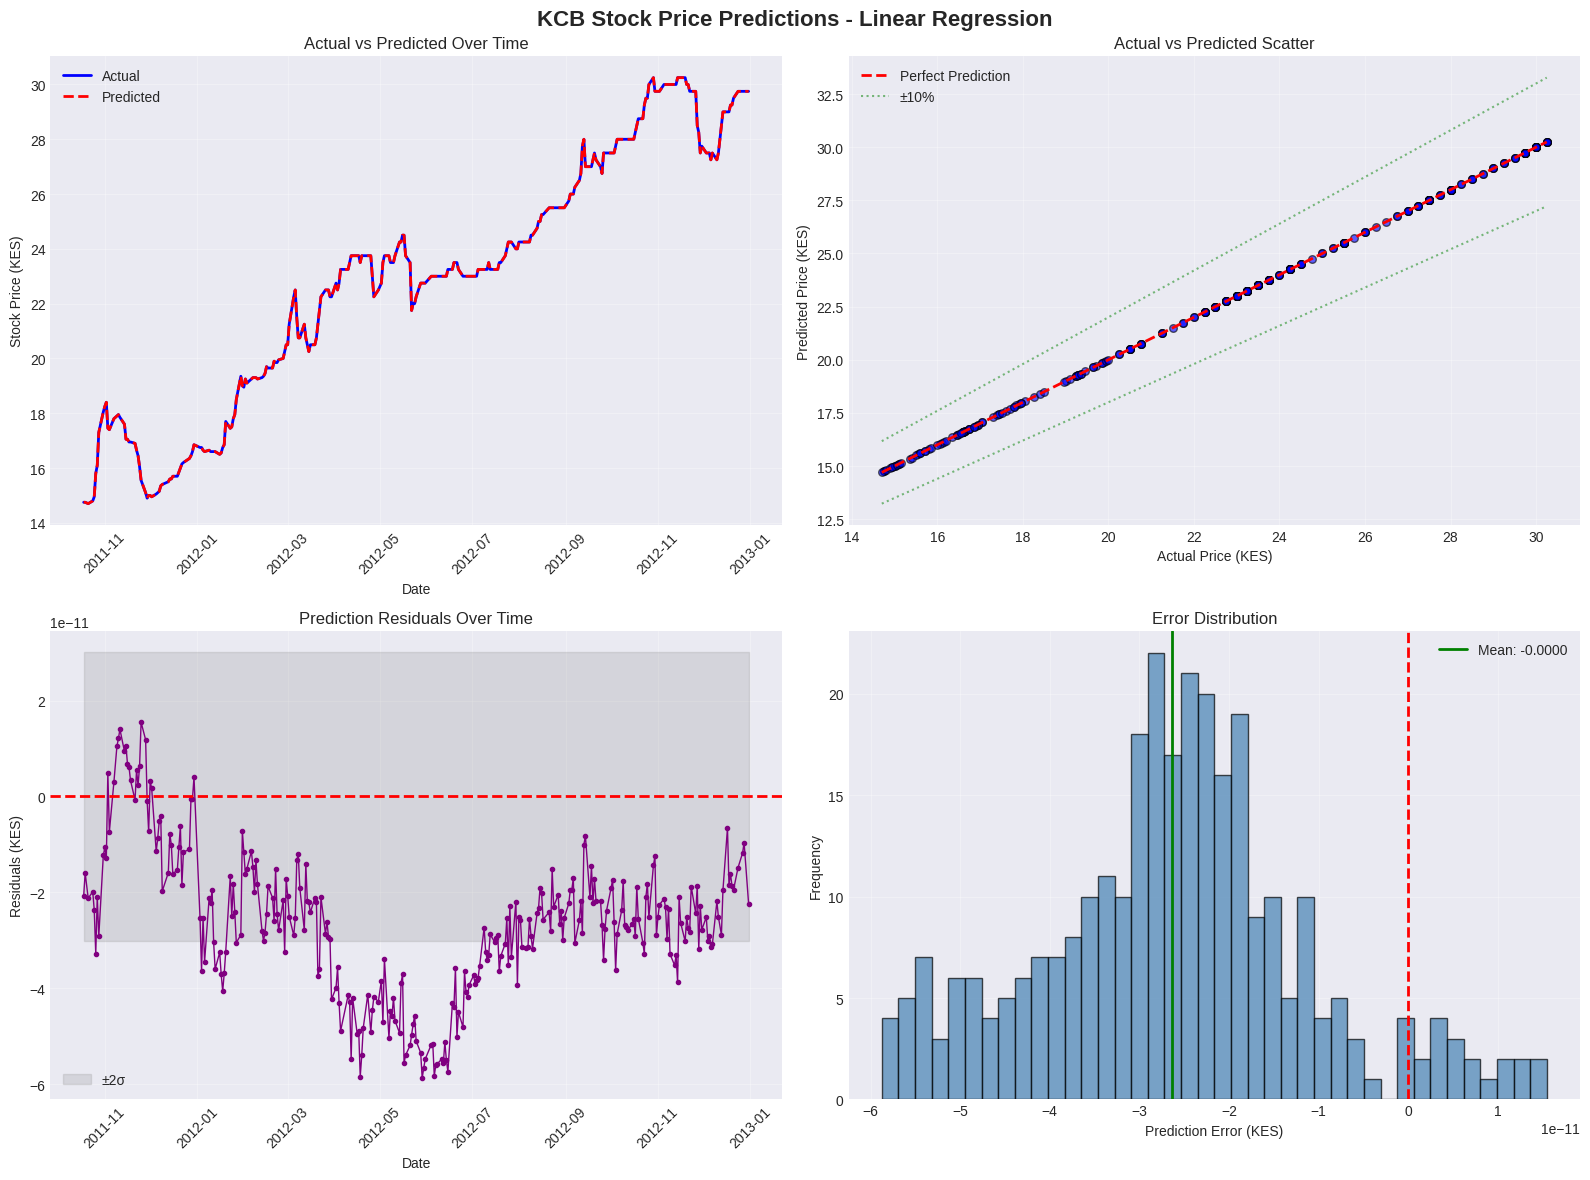

In [ ]:
def plot_final_predictions(y_test, y_pred, test_dates, model_name):
    """
    Create final prediction visualization
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'KCB Stock Price Predictions - {model_name}', fontsize=16, fontweight='bold')

    # Plot 1: Time series of actual vs predicted
    ax1 = axes[0, 0]
    ax1.plot(test_dates, y_test.values, 'b-', label='Actual', linewidth=2)
    ax1.plot(test_dates, y_pred, 'r--', label='Predicted', linewidth=2)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Stock Price (KES)')
    ax1.set_title('Actual vs Predicted Over Time')
    ax1.legend()
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Scatter plot with confidence bands
    ax2 = axes[0, 1]
    ax2.scatter(y_test.values, y_pred, alpha=0.6, s=30, c='blue', edgecolor='black')

    # Add perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    # Add ±10% bands
    ax2.plot([min_val, max_val], [min_val*1.1, max_val*1.1], 'g:', alpha=0.5, label='±10%')
    ax2.plot([min_val, max_val], [min_val*0.9, max_val*0.9], 'g:', alpha=0.5)

    ax2.set_xlabel('Actual Price (KES)')
    ax2.set_ylabel('Predicted Price (KES)')
    ax2.set_title('Actual vs Predicted Scatter')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Residuals over time
    ax3 = axes[1, 0]
    residuals = y_test.values - y_pred
    ax3.plot(test_dates, residuals, 'o-', color='purple', markersize=3, linewidth=1)
    ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax3.fill_between(test_dates, -np.std(residuals)*2, np.std(residuals)*2,
                     alpha=0.2, color='gray', label='±2σ')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Residuals (KES)')
    ax3.set_title('Prediction Residuals Over Time')
    ax3.legend()
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)

    # Plot 4: Error distribution
    ax4 = axes[1, 1]
    ax4.hist(residuals, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    ax4.axvline(x=0, color='r', linestyle='--', linewidth=2)
    ax4.axvline(x=np.mean(residuals), color='g', linestyle='-', linewidth=2,
                label=f'Mean: {np.mean(residuals):.4f}')
    ax4.set_xlabel('Prediction Error (KES)')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Error Distribution')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{VISUALIZATIONS_PATH}/final_predictions_{model_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()


# Plot final predictions
y_pred_best = best_pipeline.predict(X_test)
plot_final_predictions(y_test, y_pred_best, test_dates, best_model)

###SAVING FINAL MODEL AND RESULTS

In [ ]:
print("\n" + "="*80)
print("SAVING FINAL MODEL AND RESULTS")
print("="*80)

# Create results summary
results_summary = {
    'best_model': best_model,
    'best_model_cv_r2': float(results_df[results_df['Model']==best_model]['CV_R2'].values[0]),
    'best_model_test_r2': float(results_df[results_df['Model']==best_model]['R2'].values[0]),
    'best_model_rmse': float(results_df[results_df['Model']==best_model]['RMSE'].values[0]),
    'best_model_mae': float(results_df[results_df['Model']==best_model]['MAE'].values[0]),
    'best_model_mape': float(results_df[results_df['Model']==best_model]['MAPE'].values[0]),
    'best_model_dir_acc': float(results_df[results_df['Model']==best_model]['Dir_Acc'].values[0]),
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': X_train.shape[1],
    'train_samples': len(X_train),
    'test_samples': len(X_test)
}

# Save as JSON
with open(f'{RESULTS_PATH}/model_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=4)

# Save results dataframe
results_df.to_csv(f'{RESULTS_PATH}/all_models_performance.csv', index=False)

# Save predictions
predictions_df = pd.DataFrame({
    'Date': test_dates,
    'Actual': y_test.values,
    **{name: pred for name, pred in predictions.items()}
})
predictions_df.to_csv(f'{RESULTS_PATH}/all_predictions.csv', index=False)

print(f"\n Results saved to {RESULTS_PATH}")


SAVING FINAL MODEL AND RESULTS

 Results saved to /content/drive/MyDrive/KBS Dataset/Data/Stock_Model_Output/results


In [ ]:
def generate_final_report(results_summary, results_df, importance_df=None):
    """
    Generate a comprehensive final report
    """
    report = f"""
    {'='*80}
    KCB STOCK PRICE PREDICTION - FINAL REPORT
    {'='*80}

    EXECUTION DATE: {results_summary['training_date']}

    1. DATASET SUMMARY
    {'-'*40}
    - Training samples: {results_summary['train_samples']}
    - Testing samples: {results_summary['test_samples']}
    - Number of features: {results_summary['n_features']}

    2. BEST MODEL: {results_summary['best_model']}
    {'-'*40}
    - Cross-Validation R²: {results_summary['best_model_cv_r2']:.4f}
    - Test R²: {results_summary['best_model_test_r2']:.4f}
    - RMSE: {results_summary['best_model_rmse']:.4f} KES
    - MAE: {results_summary['best_model_mae']:.4f} KES
    - MAPE: {results_summary['best_model_mape']:.2f}%
    - Directional Accuracy: {results_summary['best_model_dir_acc']:.2%}

    3. ALL MODELS PERFORMANCE (Ranked by CV R²)
    {'-'*40}
"""

    # Add model rankings
    ranked_models = results_df.sort_values('CV_R2', ascending=False)
    for i, row in ranked_models.iterrows():
        report += f"""
    {i+1}. {row['Model']}
       - Test R²: {row['R2']:.4f} | CV R²: {row['CV_R2']:.4f} (±{row['CV_R2_std']:.4f})
       - RMSE: {row['RMSE']:.4f} | MAE: {row['MAE']:.4f} | MAPE: {row['MAPE']:.2f}%
       - Directional Accuracy: {row['Dir_Acc']:.2%}
"""

    # Add feature importance if available
    if importance_df is not None:
        report += f"""
    4. TOP 10 MOST IMPORTANT FEATURES
    {'-'*40}
"""
        for i, row in importance_df.head(10).iterrows():
            report += f"    {i+1}. {row['Feature']}: {row['Importance']:.6f}\n"

    report += f"""
    5. CONCLUSION
    {'-'*40}
    The {results_summary['best_model']} model performed best for predicting KCB stock prices,
    achieving an R² score of {results_summary['best_model_test_r2']:.4f} on test data.
    The model can predict stock prices with an average error of {results_summary['best_model_mae']:.2f} KES.

    {'='*80}
    END OF REPORT
    {'='*80}
    """

    # Save report
    with open(f'{RESULTS_PATH}/final_report.txt', 'w') as f:
        f.write(report)

    print(report)


# Generate final report
generate_final_report(results_summary, results_df, importance_df if 'importance_df' in locals() else None)

print("\n" + "="*80)
print(" PROJECT COMPLETE! ALL STEPS FINISHED SUCCESSFULLY")
print("="*80)
print(f"\n Check these folders for outputs:")
print(f"   - Models: {MODELS_PATH}")
print(f"   - Results: {RESULTS_PATH}")
print(f"   - Visualizations: {VISUALIZATIONS_PATH}")


    KCB STOCK PRICE PREDICTION - FINAL REPORT

    EXECUTION DATE: 2026-02-24 23:22:30

    1. DATASET SUMMARY
    ----------------------------------------
    - Training samples: 1200
    - Testing samples: 301
    - Number of features: 56

    2. BEST MODEL: Linear Regression
    ----------------------------------------
    - Cross-Validation R²: 1.0000
    - Test R²: 1.0000
    - RMSE: 0.0000 KES
    - MAE: 0.0000 KES
    - MAPE: 0.00%
    - Directional Accuracy: 59.47%

    3. ALL MODELS PERFORMANCE (Ranked by CV R²)
    ----------------------------------------

    1. Linear Regression
       - Test R²: 1.0000 | CV R²: 1.0000 (±0.0000)
       - RMSE: 0.0000 | MAE: 0.0000 | MAPE: 0.00%
       - Directional Accuracy: 59.47%

    2. Ridge
       - Test R²: 0.8259 | CV R²: -109.5622 (±209.7781)
       - RMSE: 1.8791 | MAE: 1.4912 | MAPE: 6.14%
       - Directional Accuracy: 31.23%

    5. Random Forest
       - Test R²: 0.9945 | CV R²: -124.0865 (±205.9949)
       - RMSE: 0.3344 | MA